# Selection of the most probable project outcome

In [1]:
import numpy as np #!pip install --upgrade numpy==1.26.4
import pandas as pd
import random
from IPython.display import display
import joblib

#diable warning printing
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Data set load
data=pd.read_csv('./data/C201905_counterfactuals/simulation_C201905_counterfactuals__ev0.1812.csv',index_col=0)


# Create a target variable, 'delay' and remove unnecessary columns
data['delay']=(data['actual_duration']>data['baseline_duration'])*1
data.drop(columns=['actual_duration','baseline_duration','critical_path'],inplace=True)
# Sort the columns
columns_sorted = sorted(data.columns, key=lambda x: int(x.replace('duration', '')) if 'duration' in x else float('inf'))
data = data[columns_sorted]
data.head(2)

,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1738.595774,1967.122966,256.504345,2186.408241,1723.181771,1898.648645,1795.289433,1599.760892,2224.382275,2489.048379,2124.279759,139.271436,8.498099,234.542254,7.655393,1
1,1717.864331,1881.352898,266.048082,2324.022291,1849.728508,2083.309016,1839.782891,1593.929687,2323.598219,2279.745524,2334.495021,145.448900,8.235859,238.908956,8.357302,1


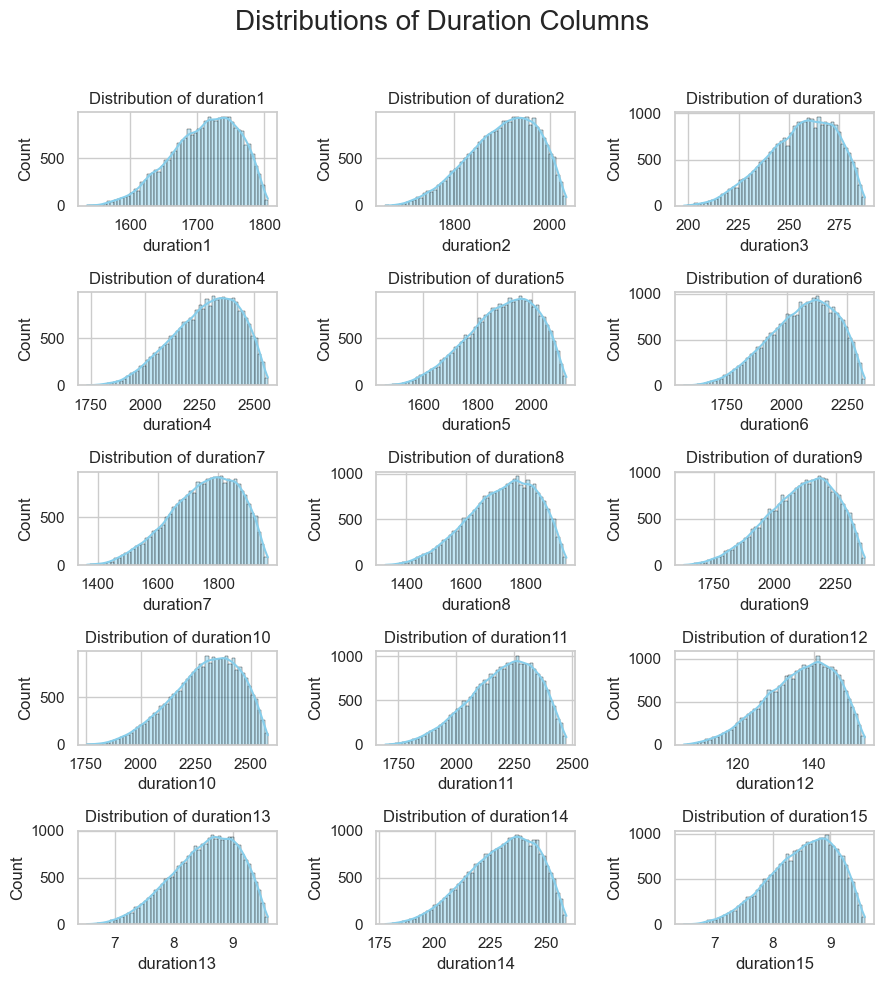

In [3]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Create a figure with 15 subplots (5 rows x 3 columns)
fig, axes = plt.subplots(5, 3, figsize=(9, 10))
fig.suptitle('Distributions of Duration Columns', fontsize=20)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop over the 15 duration columns
for i in range(15):
    col_name = f'duration{i+1}'  # e.g., duration1, duration2, ..., duration15
    ax = axes[i]

    # Plot the distribution using seaborn
    sns.histplot(data[col_name], kde=True, ax=ax, color='skyblue', edgecolor='black')

    # Set the title for each subplot
    ax.set_title(f'Distribution of {col_name}', fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show the plots
plt.show()


In [ ]:
## k-means clustering

# select the number of clusters

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Seleccionar columnas numéricas
numeric_cols = data.select_dtypes(include='number').columns
X = data[numeric_cols]

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Rango de k
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Estimar el codo con la "segunda derivada" (curvatura de la inercia)
diffs = np.diff(inertias)
second_diffs = np.diff(diffs)
best_k_elbow = k_range[np.argmin(second_diffs) + 2]  # +2 por dos diferencias sucesivas

# Mejor k por silueta
best_k_silhouette = k_range[np.argmax(silhouette_scores)]

# Graficar
plt.figure(figsize=(12, 5))

# Inercia (Elbow)
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.axvline(x=best_k_elbow, color='red', linestyle='--', label=f'Best k: {best_k_elbow}')
plt.legend()

# Silueta
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.axvline(x=best_k_silhouette, color='red', linestyle='--', label=f'Best k: {best_k_silhouette}')
plt.legend()

plt.tight_layout()
plt.show()

# Imprimir resultados
print(f"Best k according to silhouette score: {best_k_silhouette}")
print(f"Best k according to elbow method (second derivative): {best_k_elbow}")



In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Make a copy of the original DataFrame to avoid modifying it
data_copy = data.copy()

# 2. Select only numeric columns for clustering
numeric_cols = data_copy.select_dtypes(include='number').columns
X = data_copy[numeric_cols]

# 3. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Define number of clusters (e.g., best_k_silhouette or best_k_elbow)
n_clusters = best_k_silhouette  # Define this variable beforehand
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# 5. Fit KMeans and assign clusters to the copy
data_copy['cluster'] = kmeans.fit_predict(X_scaled)

# 6. Identify the majority cluster (the one with most members)
majority_cluster = data_copy['cluster'].value_counts().idxmax()

# 7. Extract rows from the majority cluster and compute Euclidean distances to centroid
cluster_mask = data_copy['cluster'] == majority_cluster
cluster_data = X_scaled[cluster_mask]
centroid = kmeans.cluster_centers_[majority_cluster]
distances = np.linalg.norm(cluster_data - centroid, axis=1)

# 8. Get the index (in data_copy) of the most representative instance
representative_local_index = distances.argmin()
representative_index = data_copy[cluster_mask].iloc[representative_local_index].name

# 9. Extract the representative instance as a DataFrame
representative_instance_df = data_copy.loc[[representative_index]]

# ✅ Show the result
print("\nMost representative instance of the majority cluster:")
print(representative_instance_df)



Most representative instance of the majority cluster:
         duration1   duration2   duration3    duration4    duration5  \
11030  1693.727106  1886.06625  257.507414  2353.736811  1883.973101   

        duration6    duration7    duration8    duration9   duration10  \
11030  2140.08145  1804.682241  1730.276268  2111.399063  2327.169221   

        duration11  duration12  duration13  duration14  duration15  delay  \
11030  2295.998461  138.809728    8.609983  219.122919     8.98823      1   

       cluster  
11030        1  


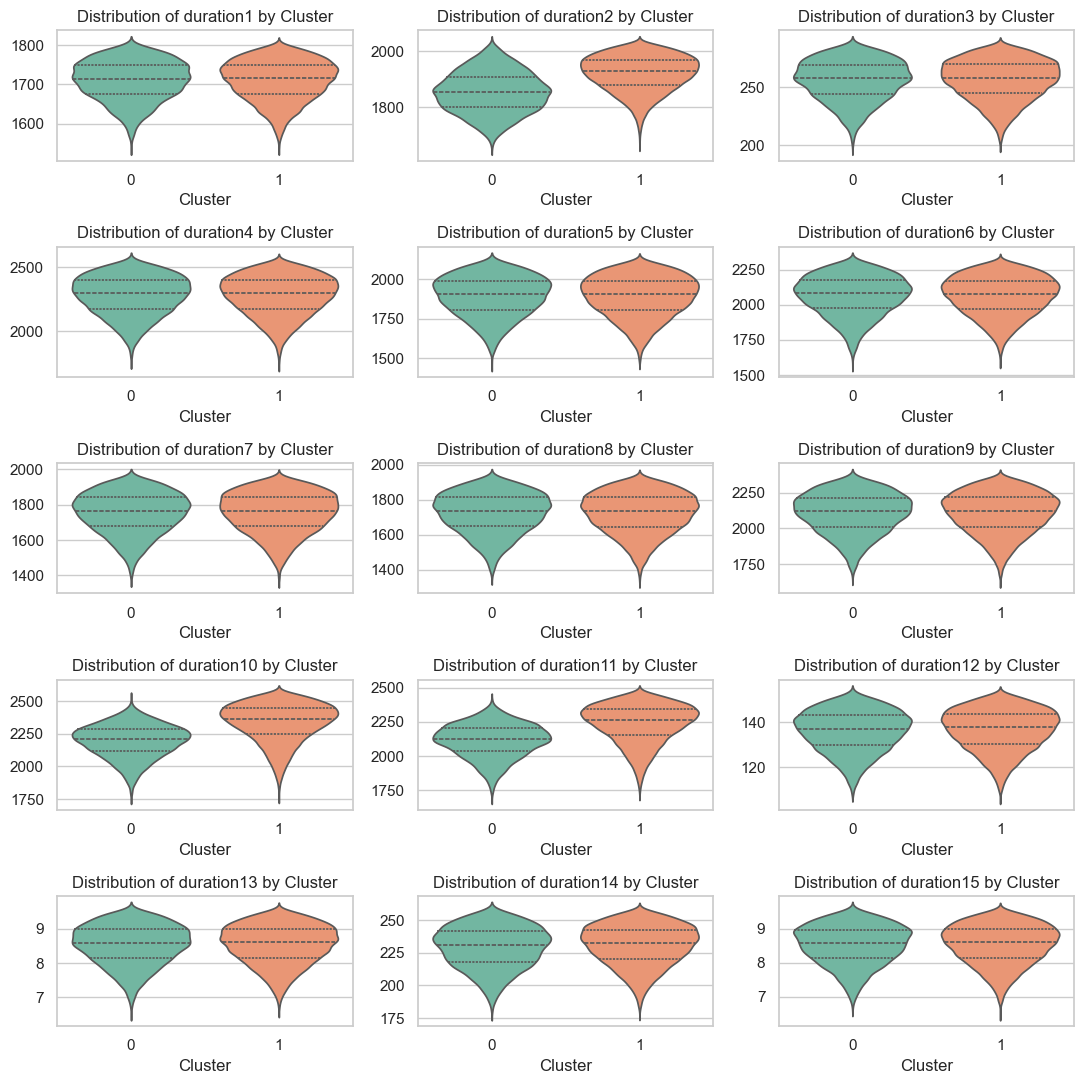

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

duration_cols = [f'duration{i}' for i in range(1, 16)]

# Crear figura
n_rows = 5
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 11))
axes = axes.flatten()

# Trazar distribución de cada duración por cluster
for i, col in enumerate(duration_cols):
    sns.violinplot(
        data=data_copy,
        x='cluster',
        y=col,
        hue='cluster',
        ax=axes[i],
        palette='Set2',
        inner='quartile',
        legend=False  # Para no repetir leyenda
)
    axes[i].set_title(f'Distribution of {col} by Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('')

# Ajustar layout
plt.tight_layout()
plt.show()


In [ ]:
# Calcular la delay media de cada cluster
delay_media_por_cluster = data_copy.groupby('cluster')['delay'].mean()
print(delay_media_por_cluster)

In [ ]:
# Get the index in the original DataFrame for the selected instance

search_for = representative_instance_df.iloc[0, 0:16]

matching = (data == search_for).all(axis=1)
matching_indices = data[matching].index

data.loc[matching_indices]


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
11030,1693.727106,1886.06625,257.507414,2353.736811,1883.973101,2140.08145,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.98823,1
